# Disease Prediction using Random Forest Classification

# Problem Statement
The early prediction of diseases is essential for timely medical intervention and improved patient outcomes. However, identifying whether a person is likely to have a disease based on multiple health and lifestyle factors can be challenging using traditional methods. This project aims to develop a machine learning model that predicts the presence or absence of a disease using patient information such as age, gender, BMI, blood pressure, cholesterol level, smoking habits, alcohol consumption, physical activity, and family history. By applying data preprocessing, exploratory data analysis (EDA), feature selection, and a Random Forest Classifier with hyperparameter tuning, the model seeks to provide accurate disease predictions and support healthcare professionals in making informed decisions.

# Data Structure


- The dataset consists of patient demographic, lifestyle, and health-related information. The objective is to analyze various health risk factors and build a machine learning model to predict whether a patient has a disease.

- Total Rows           : 1000
- Total Columns        : 11

- Independent Variables: Age, Gender, BMI, Blood Pressure,
                         Cholesterol Level, Diabetes,
                         Smoking, Alcohol Consumption,
                         Physical Activity, Family History

- Target Column        : Disease

- Target Classes       : Yes (Disease), No (No Disease)

- Problem Type         : Binary Classification Problem

- Model Used           : Random Forest Classifier

# Library Import

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


# Dataset Loaded

In [133]:
df=pd.read_csv("disease_prediction.csv")
df

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,24,Male,105,237,86,86,30.9,69,Yes,Yes,Medium,No,No
996,997,40,Male,120,219,133,72,34.3,92,Yes,Yes,Medium,No,No
997,998,44,Female,114,273,114,74,36.0,76,No,No,Low,No,Yes
998,999,31,Male,95,231,130,72,28.2,81,Yes,Yes,Medium,Yes,No


# Data Understanding

In [134]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [135]:
df.tail()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
995,996,24,Male,105,237,86,86,30.9,69,Yes,Yes,Medium,No,No
996,997,40,Male,120,219,133,72,34.3,92,Yes,Yes,Medium,No,No
997,998,44,Female,114,273,114,74,36.0,76,No,No,Low,No,Yes
998,999,31,Male,95,231,130,72,28.2,81,Yes,Yes,Medium,Yes,No
999,1000,83,Male,109,256,103,86,30.3,64,Yes,Yes,High,No,Yes


In [136]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1000
Number of columns: 14


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [138]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


In [139]:
df.describe(include='object')

,gender,smoking,alcohol_consumption,physical_activity,family_history,disease
count,1000,1000,1000,1000,1000,1000
unique,2,2,2,3,2,2
top,Female,Yes,Yes,Medium,No,Yes
freq,504,503,501,344,504,501


In [140]:
df.dtypes

patient_id               int64
age                      int64
gender                  object
glucose_mg_dl            int64
cholesterol_mg_dl        int64
systolic_bp              int64
diastolic_bp             int64
bmi                    float64
heart_rate               int64
smoking                 object
alcohol_consumption     object
physical_activity       object
family_history          object
disease                 object
dtype: object

In [141]:
for i in df.columns:
    print(f"{i}: {df[i].nunique()} unique values")  

patient_id: 1000 unique values
age: 68 unique values
gender: 2 unique values
glucose_mg_dl: 131 unique values
cholesterol_mg_dl: 188 unique values
systolic_bp: 94 unique values
diastolic_bp: 56 unique values
bmi: 206 unique values
heart_rate: 58 unique values
smoking: 2 unique values
alcohol_consumption: 2 unique values
physical_activity: 3 unique values
family_history: 2 unique values
disease: 2 unique values


In [142]:
for i in df.columns:
    print(f"{i}: {df[i].unique()}")

patient_id: [   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  195

# Data Cleaning

In [143]:
df.duplicated().sum()

np.int64(0)

In [144]:
df.isna().sum()

patient_id             0
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

# Exploratory Data Analysis

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

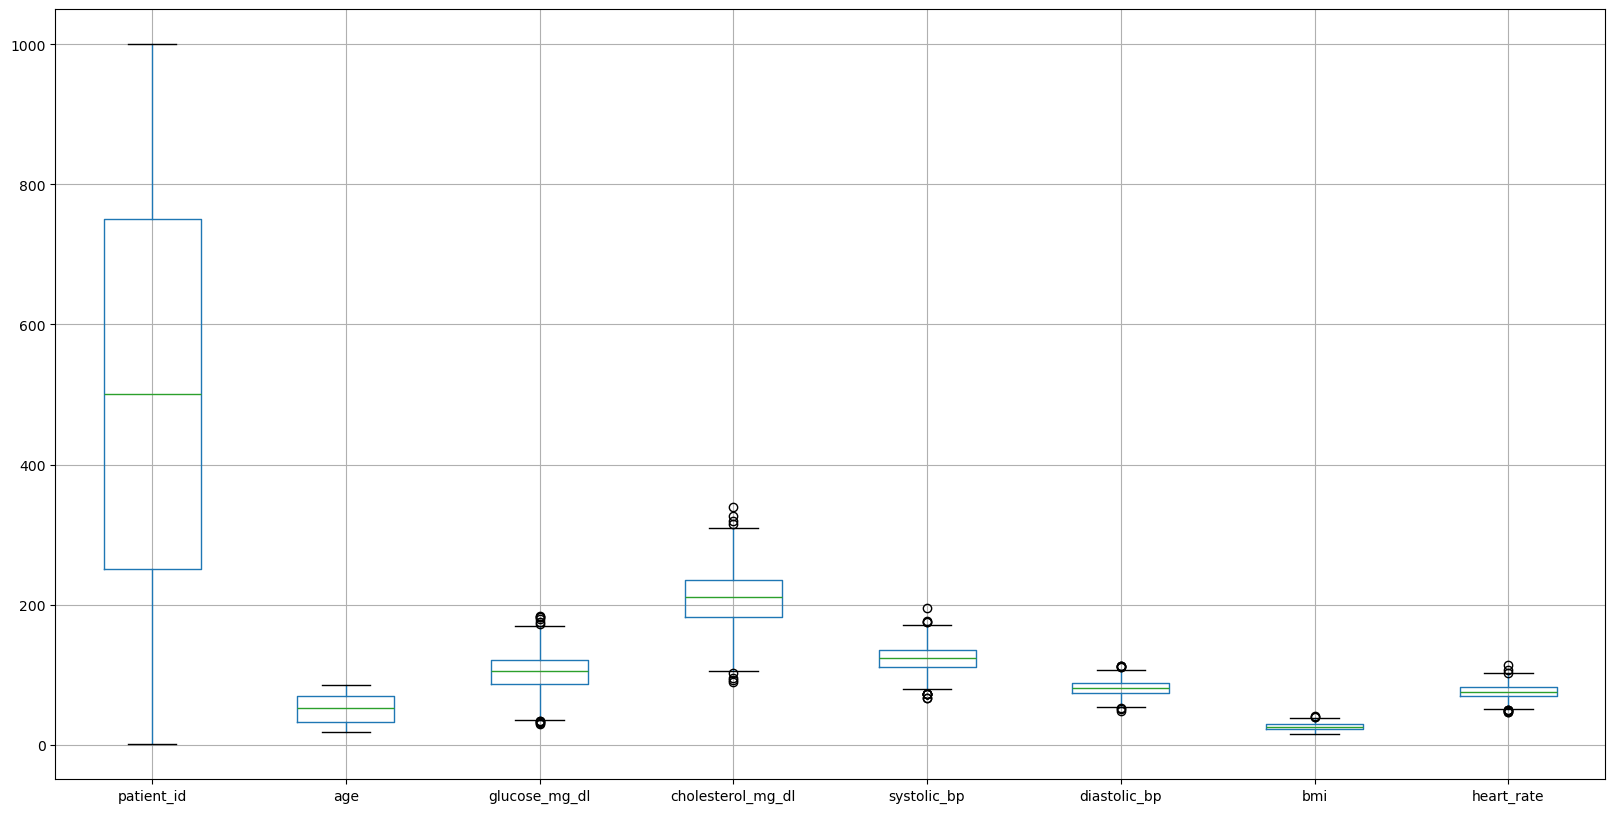

In [145]:
plt.figure(figsize=(20,10))
df.boxplot()
plt.show()

In [146]:
df.groupby('gender')['age'].count()

gender
Female    504
Male      496
Name: age, dtype: int64

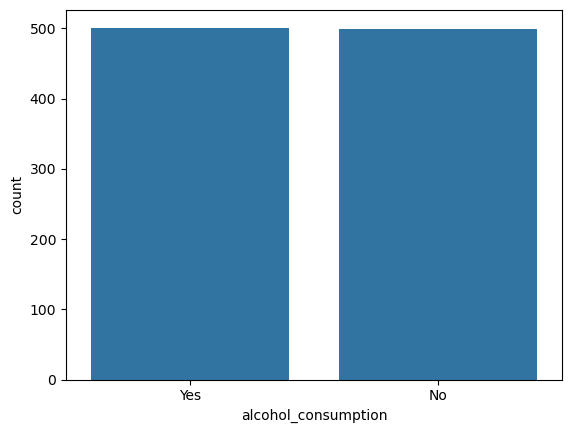

In [147]:
sns.countplot(x='alcohol_consumption', data=df)
plt.show()


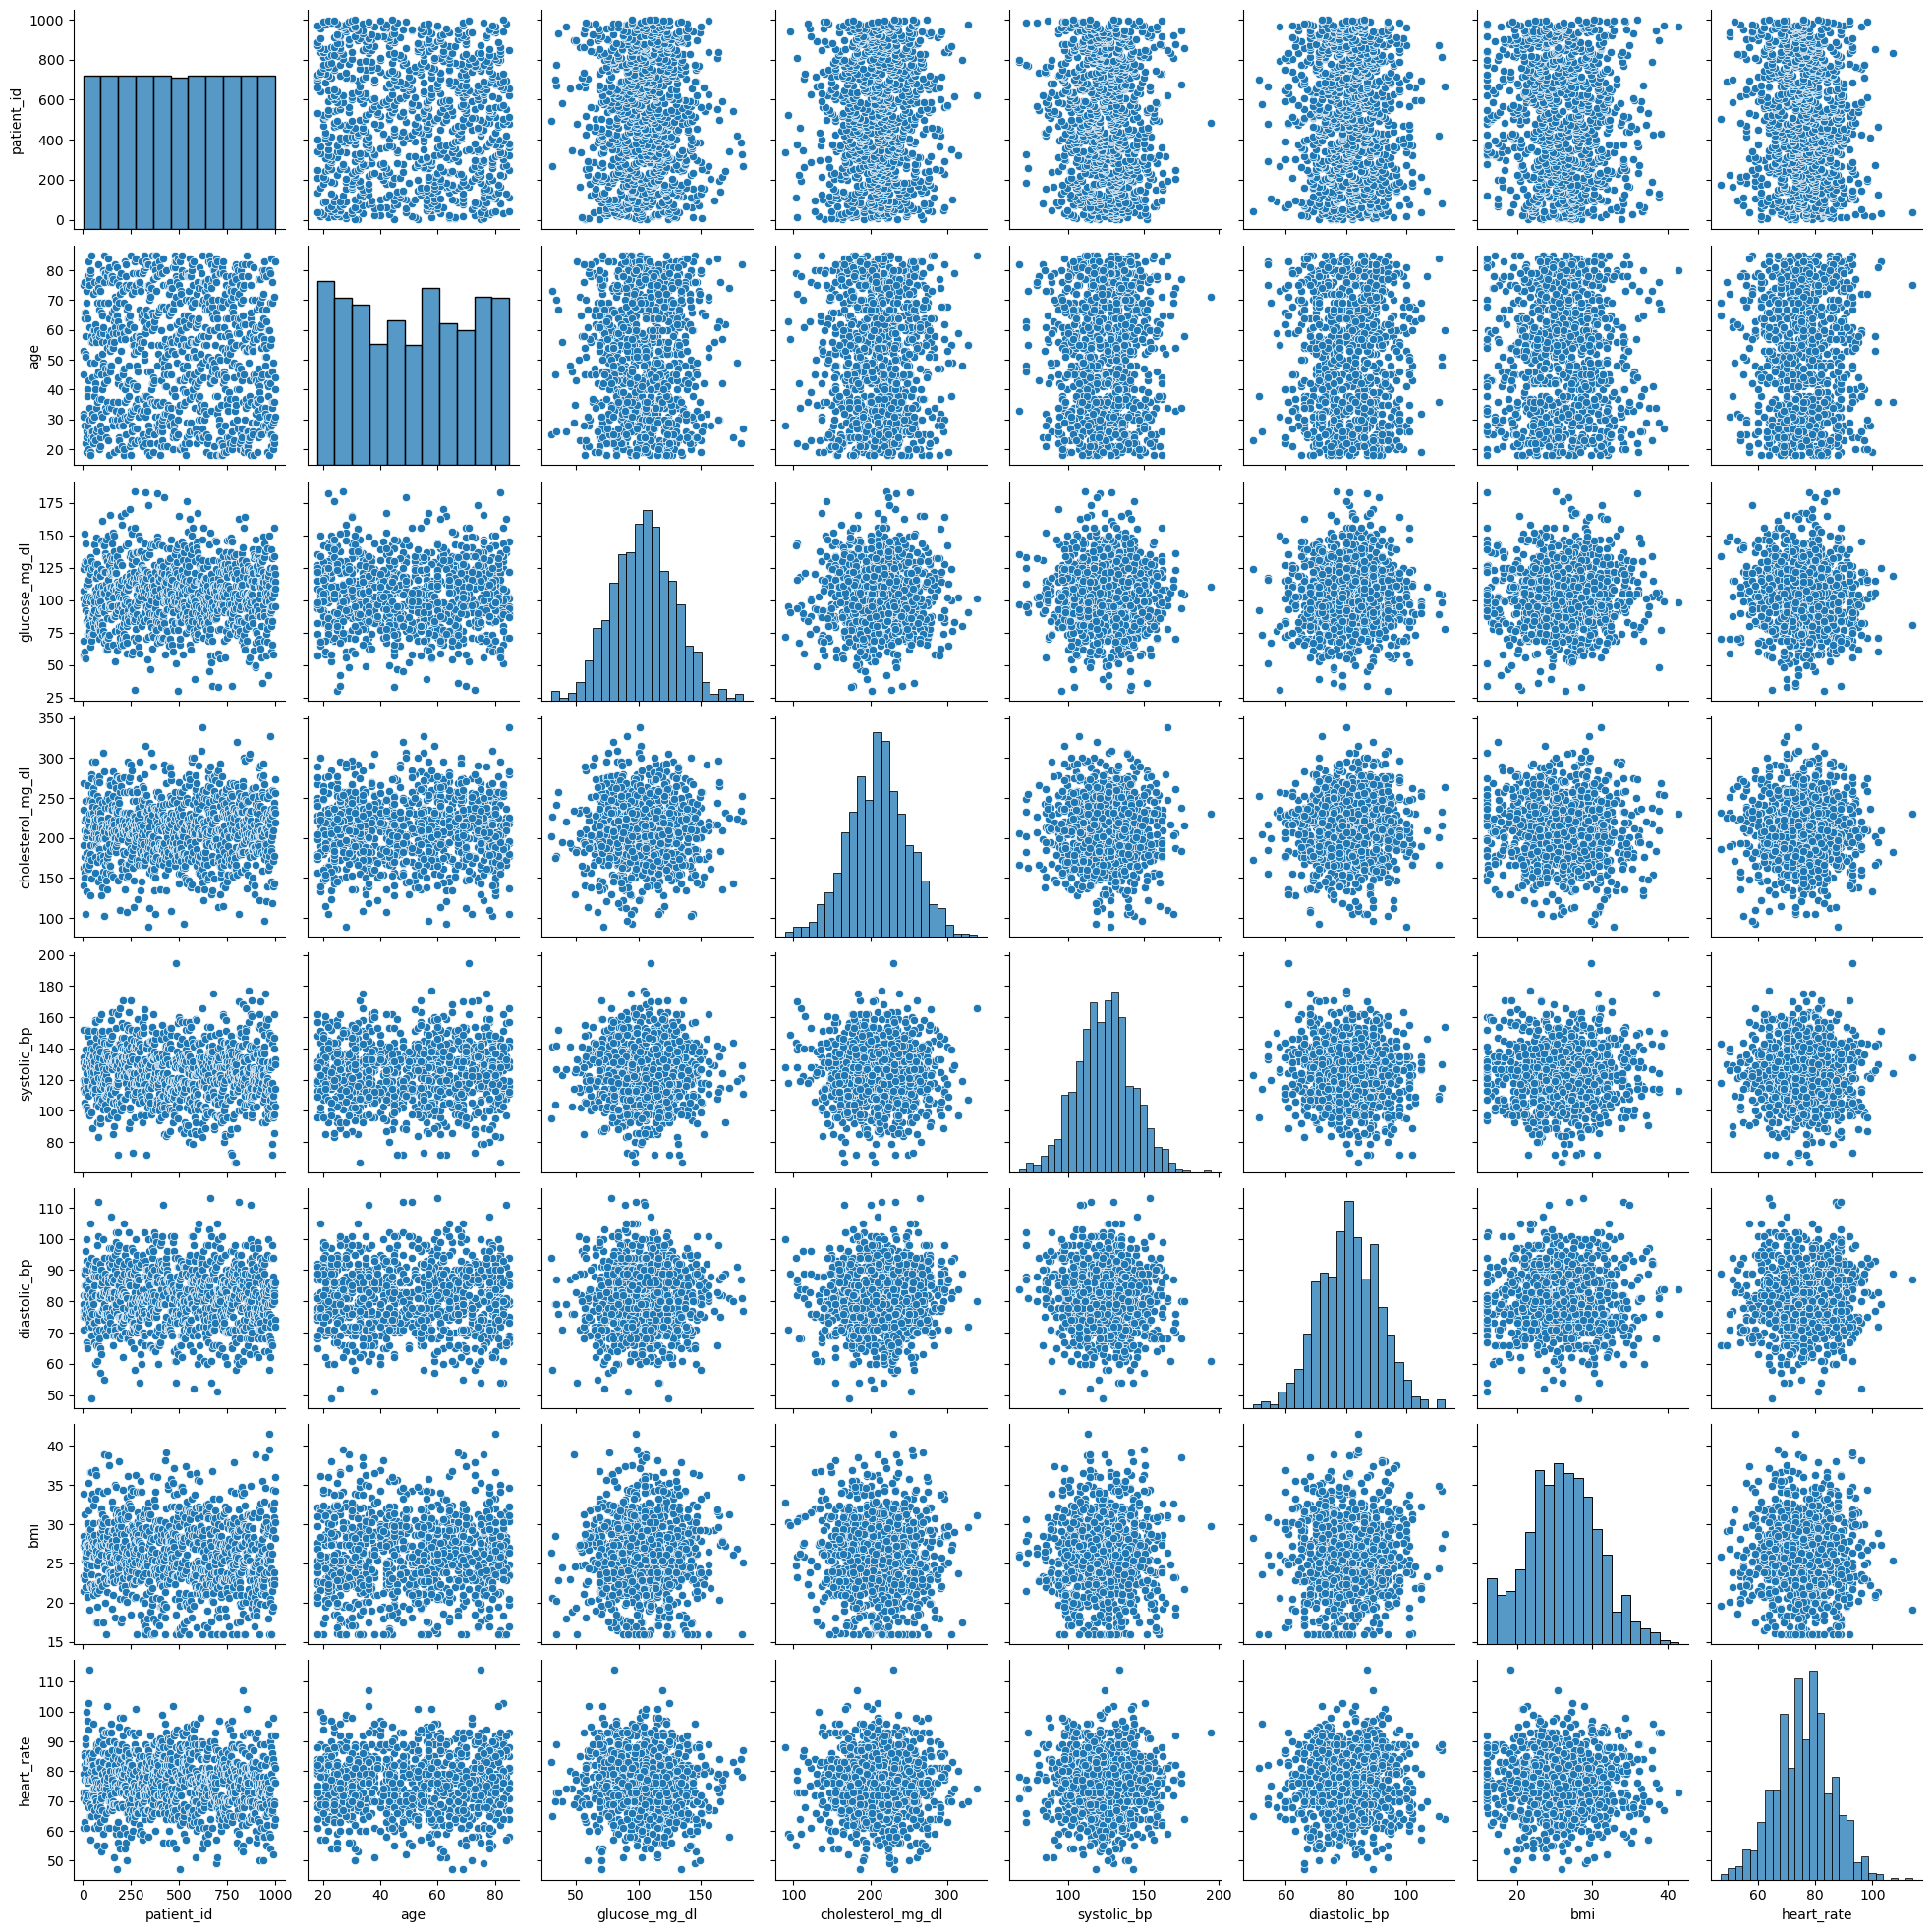

In [148]:
sns.pairplot(df)
plt.show()

# Encoding

In [149]:
for i in df.columns[df.dtypes == 'object']:
    print(f"{i}: {df[i].unique()}")

gender: ['Male' 'Female']
smoking: ['No' 'Yes']
alcohol_consumption: ['Yes' 'No']
physical_activity: ['Low' 'Medium' 'High']
family_history: ['Yes' 'No']
disease: ['Yes' 'No']


In [150]:
df['physical_activity'].value_counts()

physical_activity
Medium    344
High      344
Low       312
Name: count, dtype: int64

In [151]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['smoking'] = df['smoking'].map({'Yes': 1, 'No': 0})
df['alcohol_consumption'] = df['alcohol_consumption'].map({'Yes': 1, 'No': 0})
df['family_history'] = df['family_history'].map({'Yes': 1, 'No': 0})
df['physical_activity']=df['physical_activity'].map({'Low':0, 'Medium':1, 'High':2})

In [152]:
Le=LabelEncoder()
df['disease'] = Le.fit_transform(df['disease'])

In [153]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,1,101,235,152,79,28.5,73,0,1,0,1,1
1,2,31,1,124,191,134,77,33.9,71,0,1,0,1,1
2,3,45,1,57,141,114,71,27.2,79,1,1,0,0,0
3,4,75,0,69,268,120,82,21.5,61,1,1,1,0,1
4,5,53,1,107,163,131,75,23.3,73,1,0,0,1,1


# Split Data into X and y

In [154]:
X=df.drop('disease', axis=1)
y=df['disease']

# Train Test Split

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Selection

In [156]:
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [157]:
dtr_col=pd.Series(dtree_model.feature_importances_, index=X.columns)
dtr_imp_col=dtr_col.sort_values(ascending=False).head(8).index
dtr_imp_col

Index(['glucose_mg_dl', 'physical_activity', 'age', 'smoking', 'systolic_bp',
       'cholesterol_mg_dl', 'family_history', 'bmi'],
      dtype='object')

In [158]:
X_train=X_train[dtr_imp_col]
X_test=X_test[dtr_imp_col]

# Model Building

In [159]:
rd=RandomForestClassifier(random_state=42)
rd.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Prediction

In [160]:
y_pred=rd.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1])

# Evalution

In [161]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f'Training Accuracy: {rd.score(X_train, y_train)}')
print(f'Test Accuracy: {rd.score(X_test, y_test)}')

[[90 10]
 [ 4 96]]
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       100
           1       0.91      0.96      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200

Training Accuracy: 1.0
Test Accuracy: 0.93


# Hyperparameter Tuning

In [162]:
params={
    'min_samples_split': [2, 3, 4, 5],
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3,5,7,9,11]
}

In [163]:
gd=GridSearchCV(RandomForestClassifier(random_state=42), param_grid=params,  verbose=1)   
gd.fit(X_train, y_train) 

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [164]:
gd.best_params_

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

# Model Building with best params

In [165]:
rd=RandomForestClassifier(random_state=42,max_depth=5,min_samples_split=2,n_estimators=100)
rd.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [166]:
y_pred=rd.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [167]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f'Training Accuracy: {rd.score(X_train, y_train)}')
print(f'Test Accuracy: {rd.score(X_test, y_test)}')

[[89 11]
 [ 6 94]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       100
           1       0.90      0.94      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200

Training Accuracy: 0.9575
Test Accuracy: 0.915


# Conclusion
The Random Forest Classification model was successfully developed to predict whether a patient has a disease based on demographic, lifestyle, and health-related attributes. After preprocessing the data, performing feature selection, and tuning the model, the classifier achieved 95.75% training accuracy and 91.5% testing accuracy, indicating good generalization with only a small difference between training and testing performance.
The confusion matrix shows that the model correctly classified 89 out of 100 non-disease cases and 94 out of 100 disease cases, with only 17 misclassifications out of 200 test samples. The model achieved an overall accuracy of 92%, with precision (0.90–0.94), recall (0.89–0.94), and F1-score (0.91–0.92), demonstrating balanced and reliable performance for both classes.

Overall, the Random Forest model effectively predicts disease status and can serve as a useful decision-support tool for early disease detection. Further improvements could include using a larger dataset, additional health-related features, and comparing the performance with other machine learning algorithms such as XGBoost, LightGBM, or CatBoost